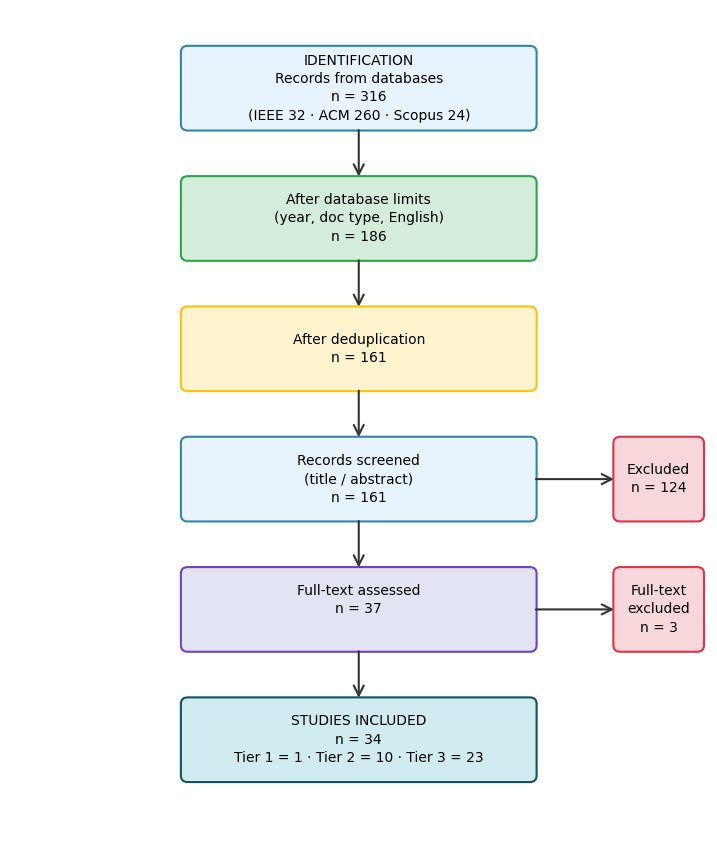

In [1]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(9, 11))
ax.set_xlim(0, 10); ax.set_ylim(0, 13); ax.axis('off')

def box(x, y, w, h, text, color='#E8F4FD', edge='#2E86AB'):
    patch = FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.05,rounding_size=0.1",
                          linewidth=1.5, facecolor=color, edgecolor=edge)
    ax.add_patch(patch)
    ax.text(x + w/2, y + h/2, text, ha='center', va='center', fontsize=10, linespacing=1.4)

def arrow(x1, y1, x2, y2):
    ax.add_patch(FancyArrowPatch((x1, y1), (x2, y2), arrowstyle='->', mutation_scale=18, linewidth=1.5, color='#333'))

box(2.5, 11.2, 5, 1.2, 'IDENTIFICATION\nRecords from databases\nn = 316\n(IEEE 32 · ACM 260 · Scopus 24)')
arrow(5, 11.2, 5, 10.4)
box(2.5, 9.2, 5, 1.2, 'After database limits\n(year, doc type, English)\nn = 186', '#D4EDDA', '#28A745')
arrow(5, 9.2, 5, 8.4)
box(2.5, 7.2, 5, 1.2, 'After deduplication\nn = 161', '#FFF3CD', '#FFC107')
arrow(5, 7.2, 5, 6.4)
box(2.5, 5.2, 5, 1.2, 'Records screened\n(title / abstract)\nn = 161')
arrow(7.5, 5.8, 8.7, 5.8); box(8.7, 5.2, 1.2, 1.2, 'Excluded\nn = 124', '#F8D7DA', '#DC3545')
arrow(5, 5.2, 5, 4.4)
box(2.5, 3.2, 5, 1.2, 'Full-text assessed\nn = 37\n', '#E2E3F3', '#6F42C1')
arrow(7.5, 3.8, 8.7, 3.8); box(8.7, 3.2, 1.2, 1.2, 'Full-text\nexcluded\nn = 3', '#F8D7DA', '#DC3545')
arrow(5, 3.2, 5, 2.4)
box(2.5, 1.2, 5, 1.2, 'STUDIES INCLUDED\nn = 34\nTier 1 = 1 · Tier 2 = 10 · Tier 3 = 23', '#D1ECF1', '#0C5460')

plt.savefig('prisma_flow_nice.png', dpi=300, bbox_inches='tight')

In [3]:
import plotly.graph_objects as go

labels = [
    "Tier 1 Core (53)", "Tier 2 Algorithmic (78)", "Tier 3 Hardware (185)",
    "ACM T1 (6)", "ACM T2 (27)", "ACM T3 (98)",
    "IEEE T2 (1)", "IEEE T3 (31)",
    "Scopus T1 (1)", "Scopus T3 (22)",
    "Retained after limits (186)", "Excluded by limits (130)"
]

# Tier1: 6+1+46=53 | Tier2:27+1+50=78 | Tier3:98+31+22+34=185
source = [0,0,0,  1,1,1,  2,2,  3,4,5,6,7,8,9]
target = [3,8,11, 4,6,11, 5,7,9,11, 10,10,10]
value  = [6,1,46, 27,1,50, 98,31,22,34, 6,27,98,1,31,1,22]

fig = go.Figure(data=[go.Sankey(
    node=dict(pad=20, thickness=20, label=labels, line=dict(color="black", width=0.5)),
    link=dict(source=source, target=target, value=value)
)])
fig.update_layout(title_text="Search strategy breakdown by tier and database (corrected)", font_size=12, height=650)
fig.write_image("tier_sankey_corrected.png", scale=2)
fig.write_html("tier_sankey_corrected.html")